<xarray.Dataset> Size: 3GB
Dimensions:    (time: 62, longitude: 1440, latitude: 721)
Coordinates:
  * time       (time) datetime64[ns] 496B 2003-01-01 ... 2003-01-31T12:00:00
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
Data variables:
    pm1        (time, latitude, longitude) float32 257MB ...
    pm2p5      (time, latitude, longitude) float32 257MB ...
    pm10       (time, latitude, longitude) float32 257MB ...
    u10        (time, latitude, longitude) float64 515MB ...
    v10        (time, latitude, longitude) float64 515MB ...
    t2m        (time, latitude, longitude) float64 515MB ...
    msl        (time, latitude, longitude) float64 515MB ...
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Sat May 31 16:31:54 2025: cdo merge /media/akhtarmunir/Extr...
    CDO:          Climate 

/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/l/users/fahad.khan/akhtar/Pangu/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


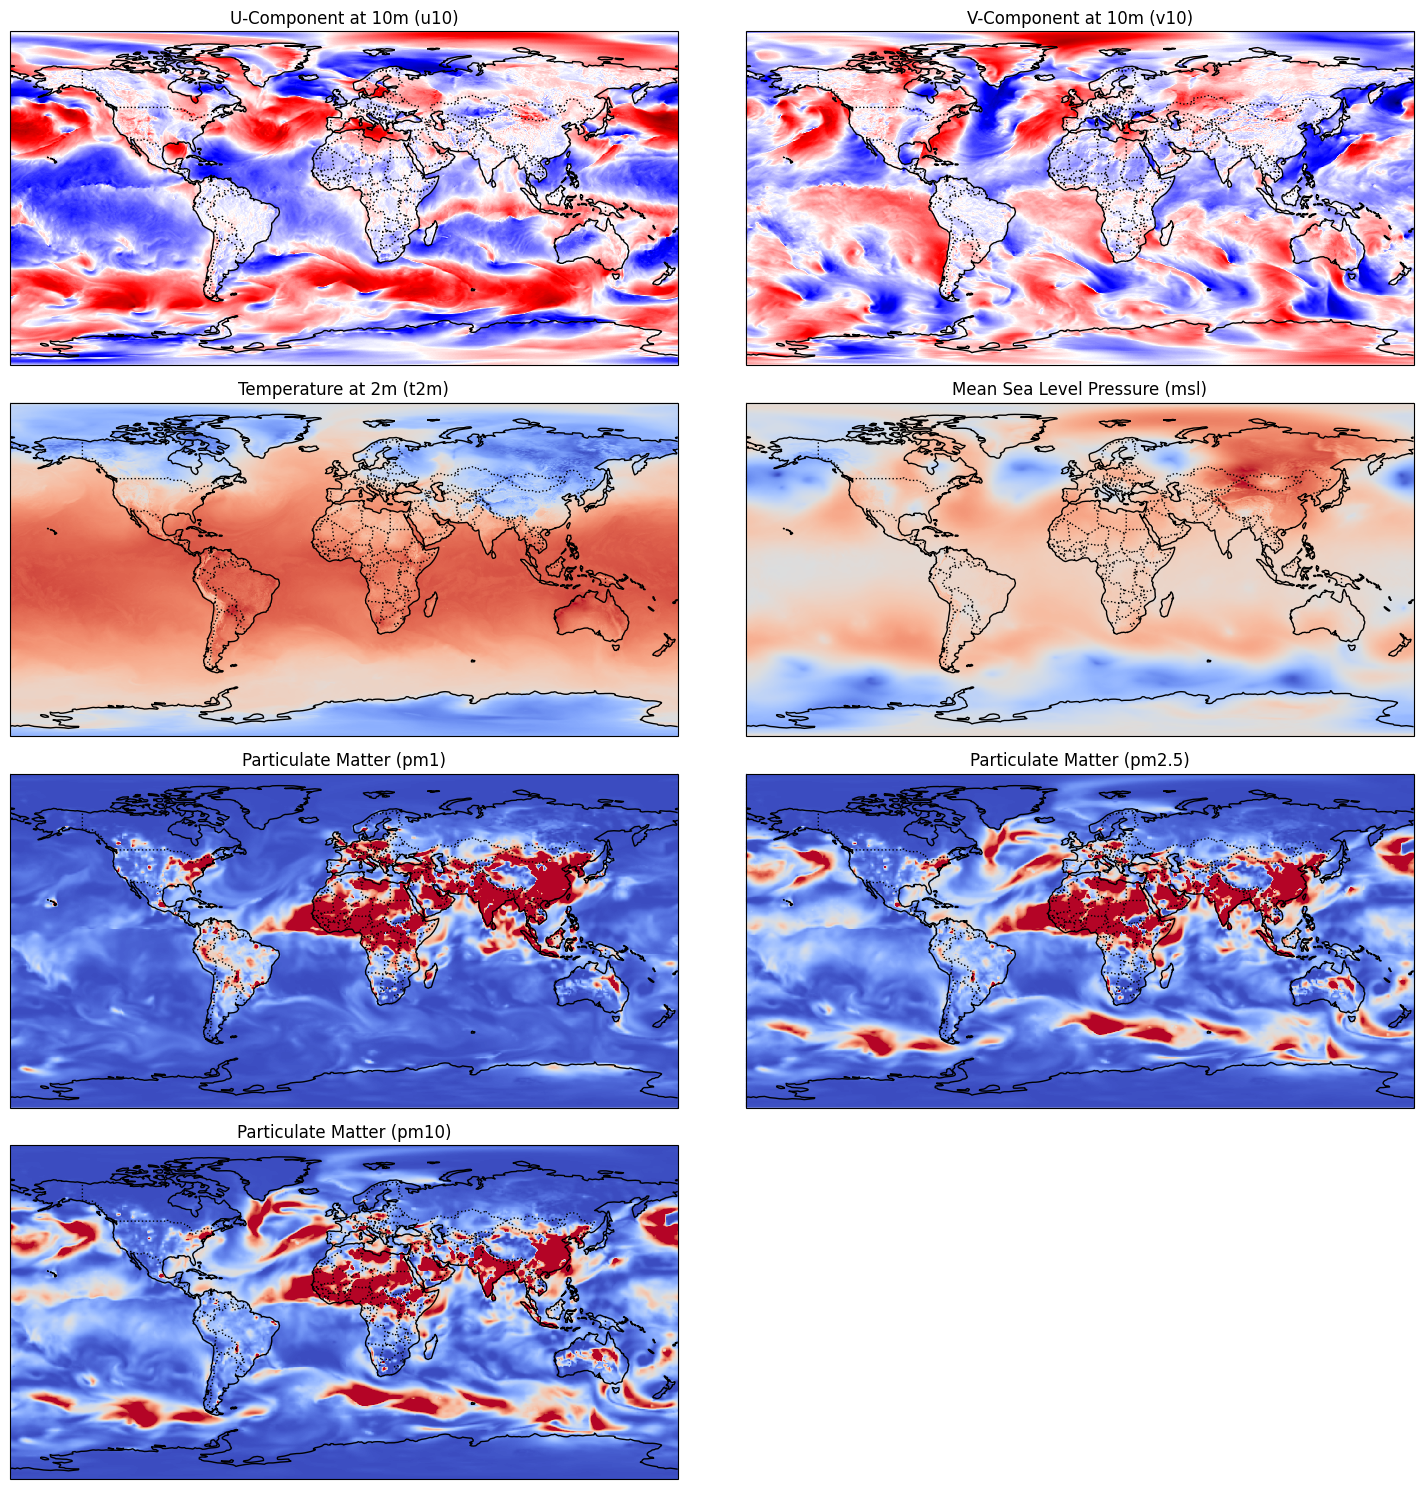

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the dataset
ds = xr.open_dataset('/l/users/fahad.khan/akhtar/Pangu/data/pangu_data/surface/surface_200301.nc')
print(ds)

# Extract the first time point
first_time = ds.isel(time=0)

# Set up the plotting figure with a 4x2 grid
fig, axs = plt.subplots(4, 2, figsize=(15, 15), subplot_kw={'projection': ccrs.PlateCarree()})

# Define the variables and their titles, along with color maps
variables = ['u10', 'v10', 't2m', 'msl', 'pm1', 'pm2p5', 'pm10']
titles = ['U-Component at 10m (u10)', 'V-Component at 10m (v10)', 'Temperature at 2m (t2m)', 'Mean Sea Level Pressure (msl)', 'Particulate Matter (pm1)', 'Particulate Matter (pm2.5)', 'Particulate Matter (pm10)']
colormaps = ['seismic', 'seismic', 'coolwarm', 'coolwarm', 'coolwarm', 'coolwarm', 'coolwarm']
pm_vars = ['pm1', 'pm2p5', 'pm10']

# Loop over the variables and plot each one
for i, var in enumerate(variables):
    ax = axs[i // 2, i % 2]
    data = first_time[var]

    if var in pm_vars:
        # Compute the 5th and 95th percentiles
        vmin = float(data.quantile(0))
        vmax = float(data.quantile(0.95))
        im = data.plot(ax=ax, cmap=colormaps[i], vmin=vmin, vmax=vmax, add_colorbar=False)
    else:
        im = data.plot(ax=ax, cmap=colormaps[i], add_colorbar=False)

    ax.coastlines(resolution='110m', color='black')
    ax.add_feature(cfeature.BORDERS, linestyle=':', color='black')
    ax.set_title(titles[i])

# Remove the last empty subplot
fig.delaxes(axs[3, 1])

# Adjust layout and show the plot
plt.tight_layout()
plt.show()